# MERFISH preprocessing

Register each section image to the CCF, pull the registered cell coordinates and gene counts
together into an AnnData, integrate across sections with scVI, select the LC-NE clusters
(high `Dbh` / `Th` / `Slc6a2`), and save the subset.

Set `run_batchprocess=True` (next cell) to re-run the per-section image registration; otherwise the
registered CSVs are loaded from scratch, falling back to the read-only data asset.

In [1]:
run_batchprocess = True

In [2]:
import os, glob, re, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
from PIL import Image

import scanpy as sc
import anndata as ad
import scvi

sys.path.append('/root/capsule/code/')
from prepare_img_utils import *
from registerCCF_util import *
from utils import get_paths

In [3]:
def get_record(s):
    """Flatten one QuickNII slice's anchoring vector into CCF anchor coordinates."""
    return {
        'filename':s.get('filename'),
        'height': s.get('height'),
        'width': s.get('width'),
        'ox': s.get('anchoring')[0],
        'oy': s.get('anchoring')[1],
        'oz': s.get('anchoring')[2],
        'ux': s.get('anchoring')[3],
        'uy': s.get('anchoring')[4],
        'uz': s.get('anchoring')[5],
        'vx': s.get('anchoring')[6],
        'vy': s.get('anchoring')[7],
        'vz': s.get('anchoring')[8],
    }

In [5]:
paths = get_paths()
paths

{'transcriptomics_dataset': 'LCNE-transcriptomics-preprocessing-from-R_202',
 'merfish_dataset': 'Nardone_2024_merfish_processing',
 'package_root': PosixPath('/root/capsule'),
 'data_root': PosixPath('/root/capsule/data'),
 'merfish_root': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing_2024-03-04_00-00-00'),
 'merfish_metadata': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing_2024-03-04_00-00-00/metadata'),
 'registered_output': PosixPath('/root/capsule/data/Nardone_2024_merfish_processing_2024-03-04_00-00-00/registered'),
 'registered_scratch': PosixPath('/root/capsule/scratch/Nardone_2024_merfish_processing/registered'),
 'transcriptomics_root': PosixPath('/root/capsule/data/LCNE-transcriptomics-preprocessing-from-R_2026-07-13_13-43-23'),
 'snRNAseq_h5ad': PosixPath('/root/capsule/data/LCNE-transcriptomics-preprocessing-from-R_2026-07-13_13-43-23/snRNAseq_LCNE.h5ad'),
 'retroseq_raw': PosixPath('/root/capsule/data/LCNE-transcriptomics-preprocessing-from-

In [6]:
scaling_factor = 1/32   # cell images are at 25 um resolution
all_file_path = os.path.join(paths['merfish_root'], 'image_xml', '*.jpg')

In [7]:
slicename_all = [os.path.basename(f).split('cell_img_')[1].split('.')[0] for f in glob.glob(all_file_path)]
slicename_all.sort()
print(slicename_all, len(slicename_all))

['MouseC_C2', 'MouseC_C3', 'MouseC_C4', 'MouseC_C5', 'MouseEg_B3', 'MouseEg_Eg1', 'MouseEg_Eg2', 'MouseEg_Eg3', 'MouseEg_Eg4', 'MouseEg_Eg5', 'MouseF_F1', 'MouseF_F2', 'MouseF_F3', 'MouseF_F4', 'MouseZM_ZM0', 'MouseZM_ZM1', 'MouseZM_ZM2', 'MouseZM_ZM3', 'MouseZM_ZM4', 'MouseZM_ZM5p1', 'MouseZM_ZM5p2', 'MouseZM_ZM6p1', 'MouseZM_ZM7p1', 'MouseZM_ZM7p2'] 24


# Register sections to the CCF
Map each section's cell coordinates into Allen CCF space using the QuickNII / VisuAlign alignment files; writes one `registered_*.csv` per section.

In [8]:
HOMEDIR = str(paths['merfish_root'])

In [9]:
if run_batchprocess:
    slicenum = ['1']
    slicenum=[int(i) for i in slicenum]

    registered_output = paths['registered_scratch']
    os.makedirs(registered_output, exist_ok=True)

    for name_of_slice in slicename_all:
        image_files=glob.glob(HOMEDIR + f'/image_xml/*{name_of_slice}.jpg')
        # load your file
        flat_name=[]
        for i in image_files:
            result=re.search('(.*).jpg', i)
            n=result.group(1)+('_nl.flat')
            flat_name+=[n]
        assert(len(image_files)==1)
        with Image.open(image_files[0]) as im:
            w, h = im.size
        json_name=image_files
        d = {'slicenum': slicenum, 'json_name': json_name,'flat_name':flat_name}
        name_df=pd.DataFrame(data=d)
        neurons=pd.read_csv(HOMEDIR+f'/filt_neurons_all/filt_neurons_{name_of_slice}.csv')
        neurons=neurons[neurons['slice'].isin(slicenum)]
        neurons['rescale_x']=neurons['x']*scaling_factor
        neurons['rescale_y']=neurons['y']*scaling_factor
        neurons['rescale_x'] = neurons['rescale_x'].astype(float)+500 # accounts for the padding added to the image
        neurons['rescale_y'] = neurons['rescale_y'].astype(float)+500

        # load visualign results
        with open(HOMEDIR+f'/visualign_rez/{name_of_slice}.json') as f:
            vafile=json.load(f)
        details={s.get('filename'):s for s in vafile['slices']}
        assert(name_of_slice in list(details.keys())[0])

        rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.name), name_df,details)).reset_index(drop=True)
        neurons[['adjusted_x', 'adjusted_y']]= rez
        neurons_nl=neurons.copy()
        neurons_nl['clustid'] =neurons_nl['clustid'].astype(str)

        # load quicknii results
        f = open(HOMEDIR+f'/quicknii_rez/quicknii_{name_of_slice}.json','r')
        data=json.loads(f.read())
        anchor=pd.DataFrame.from_records([get_record(s) for s in data['slices']])
        f.close()

        vox_dfs = []
        for slice_num, df in neurons_nl.groupby('slice'):
            quicknii_cord = get_quicknii_cord(slice_num, df,name_df,anchor,h,w) # Height and Width of image file
            vox_cord = get_vox_cord(quicknii_cord)
            vox_dfs += [vox_cord]
        vox_df = pd.concat(vox_dfs)

        vox_df.to_csv(os.path.join(registered_output, f'registered_{name_of_slice}.csv'), index=False)
else:
    print('skip the batch process!')

/tmp/ipykernel_13051/994625526.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.name), name_df,details)).reset_index(drop=True)
/tmp/ipykernel_13051/994625526.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.

#  now pull all these together 

In [10]:
reg_file_path = str(paths['registered_scratch']) +'/'
pprint(glob.glob(reg_file_path+'*'))

['/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_B3.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM3.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseC_C3.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg1.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM5p2.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseZM_ZM6p1.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseF_F1.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg5.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseC_C5.csv',
 '/root/capsule/scratch/Nardone_2024_merfish_processing/registered/registered_MouseEg_Eg3.csv',
 '/root/capsule/scratch/Nardone_2024_merfis

# load all the coords + genes

In [11]:

genecounts_all = dict()
reg_points_all = dict()
for name in slicename_all:  
    
    # load re-registered CSVs from scratch; fall back to the read-only data asset if absent
    scratch_reg = os.path.join(str(paths['registered_scratch']), f'registered_{name}.csv')
    data_reg    = os.path.join(str(paths['registered_output']), f'registered_{name}.csv')
    reg_points_path = scratch_reg if os.path.exists(scratch_reg) else data_reg
    df = pd.read_csv(reg_points_path, on_bad_lines='skip')[['neuron_id','x_CCF','y_CCF','z_CCF']]    
    reg_points_all[name] = df
    
    thisdircheck = str(paths['merfish_metadata']) + '/' + name + '/' + 'analyzed_data/*/region_*/'
    alltifregions = np.array([[s for s in m.split('/') if 'region' in s][0] for m in glob.glob(thisdircheck + '/images/*.tif')])
    values, counts = np.unique(alltifregions, return_counts=True)
    region_chosen = values[np.argmax(counts)]
    thisdircheck = str(paths['merfish_metadata']) + '/' + name + '/' + f'analyzed_data/*/{region_chosen}/'

    cell_loc_path = glob.glob(thisdircheck + 'cell_metadata.csv')[0]
    countmatrix_path = glob.glob(thisdircheck+'cell_by_gene.csv')[0]
    count_mtx = pd.read_csv(countmatrix_path, index_col=0).sort_index()
    genecounts_all[name] = count_mtx

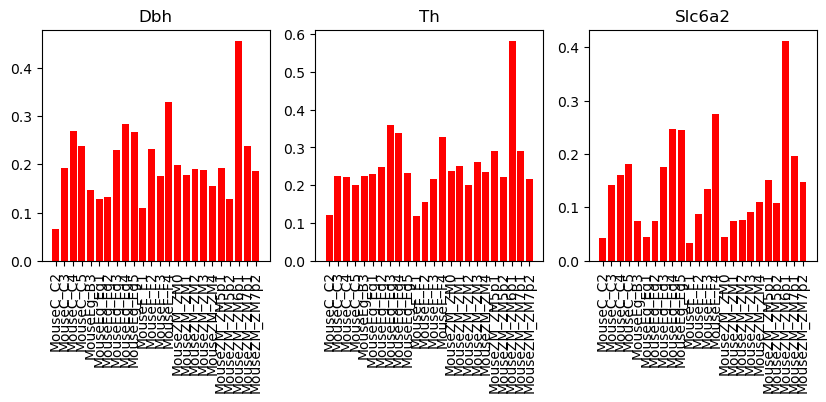

In [12]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
plt.figure(figsize = (10, 3))
for k,g in enumerate(markergenes):
    plt.subplot(1,3,k+1)
    for k, v in genecounts_all.items():
        expr = np.array(v[g]).flatten()
        plt.bar(k,np.mean(expr), color = 'red')
    plt.xticks(rotation=90);
    plt.title(g)
    


In [13]:
out_df_gene = []
out_df_loc = []
for p,name in enumerate(slicename_all):
    totalexpression = np.prod(np.array([genecounts_all[name][k].values for k in markergenes]), 0)
     # Boolean to indicaet if all three marker genes have to be expressed  in this cell!
    keptcellID = totalexpression>10   # if this is zero, we will have 7k cells. if this is 10 then we will have 5.4k cells
    
    # for gene counts
    foo_df = genecounts_all[name].iloc[keptcellID] 
    foo_df= foo_df.assign(slicename=list(np.repeat(name,(keptcellID).sum())))
    out_df_gene.append(foo_df)
    
    # for locations
    foo_df = reg_points_all[name].iloc[keptcellID]
    foo_df.index = foo_df['neuron_id']
    out_df_loc.append(foo_df)
    
out_df_gene = pd.concat(out_df_gene)    
out_df_loc = pd.concat(out_df_loc)    
out_df_gene.index.name = 'neuron_id'

In [14]:
df = pd.concat((out_df_loc, out_df_gene), axis=1)
print("combined cells x (location + gene) columns:", df.shape)

combined cells x (location + gene) columns: (5473, 390)


# build the MERFISH AnnData
Drop the Blank/CCF columns, assemble the counts into `adata_mer`, attach the CCF spatial coordinates
and per-mouse name/sex, and keep only cells expressing the LC-NE marker genes.

In [15]:
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]

df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")


In [16]:

allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    

In [17]:
# per-mouse sex, from the Nardone 2024 dataset metadata
mouse_sex_map = {'MouseC': 'M', 'MouseEg': 'F', 'MouseF': 'F', 'MouseZM': 'M'}

adata_mer.obsm["spatial"] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.raw = adata_mer.copy()
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer.obs["slicename"] = adata_mer.obs["slicename"].astype("category")
adata_mer.obs['mouse_sex'] = adata_mer.obs['mouse_name'].map(mouse_sex_map)

# scvi and remove doublets (batch corrections)

In [18]:
scvi.settings.seed = 1
umap_random_state = 307
adata_mer = adata_mer.copy()
scvi.model.SCVI.setup_anndata(adata_mer, batch_key="slicename")
model = scvi.model.SCVI(adata_mer, n_layers=1, n_latent=4)
model.train()


Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [19]:
adata_mer.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state, n_neighbors=30)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=1,  random_state=umap_random_state)


/tmp/ipykernel_13051/3228789248.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_mer, resolution=1,  random_state=umap_random_state)


... storing 'mouse_name' as categorical
... storing 'mouse_sex' as categorical


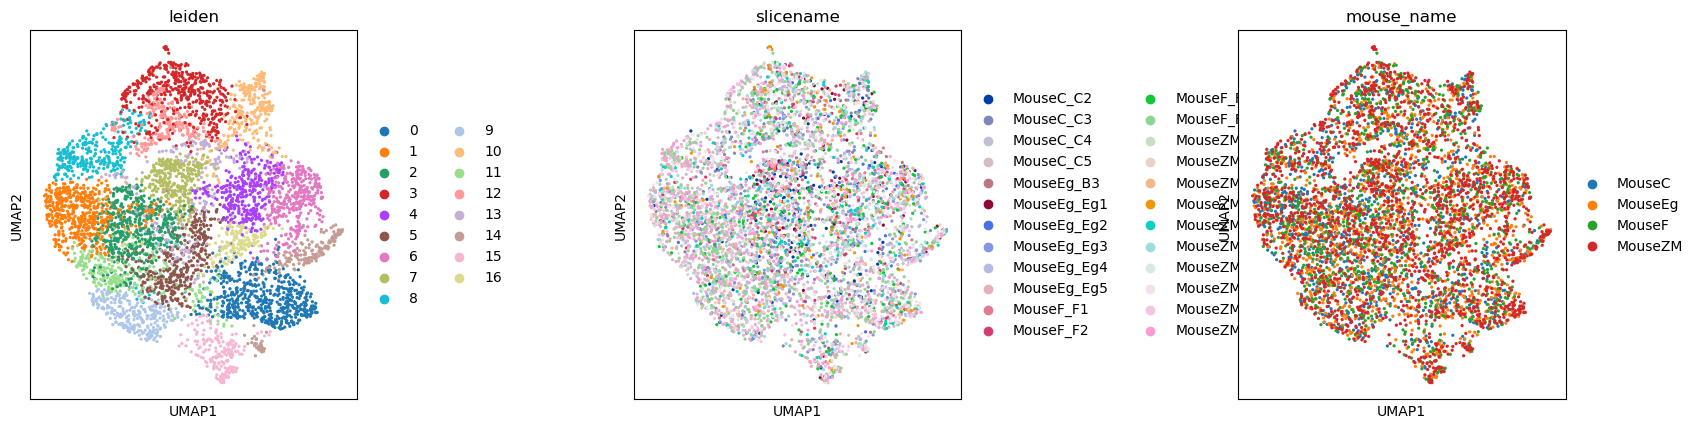

In [20]:
ax = sc.pl.umap(
    adata_mer,
    color=["leiden",'slicename','mouse_name'],show = False,
    ncols=3,
)
for a in ax:
    a.set_aspect('equal')

In [21]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print(all_batches)

[np.str_('MouseC_C2'), np.str_('MouseC_C3'), np.str_('MouseC_C4'), np.str_('MouseC_C5'), np.str_('MouseEg_B3'), np.str_('MouseEg_Eg1'), np.str_('MouseEg_Eg2'), np.str_('MouseEg_Eg3'), np.str_('MouseEg_Eg4'), np.str_('MouseEg_Eg5'), np.str_('MouseF_F1'), np.str_('MouseF_F2'), np.str_('MouseF_F3'), np.str_('MouseF_F4'), np.str_('MouseZM_ZM0'), np.str_('MouseZM_ZM1'), np.str_('MouseZM_ZM2'), np.str_('MouseZM_ZM3'), np.str_('MouseZM_ZM4'), np.str_('MouseZM_ZM5p1'), np.str_('MouseZM_ZM5p2'), np.str_('MouseZM_ZM6p1'), np.str_('MouseZM_ZM7p1'), np.str_('MouseZM_ZM7p2')]


In [22]:
X_hat_avg = model.get_normalized_expression(adata_mer,
                                            return_numpy=False,
                                            transform_batch=all_batches,
                                            library_size=1)

adata_BN = ad.AnnData(X_hat_avg.copy())
adata_BN.obs = adata_mer.obs.copy()
adata_BN.obsm = adata_mer.obsm.copy()
adata_BN.var = adata_mer.var.copy()

adata_mer.layers["BN"] = X_hat_avg

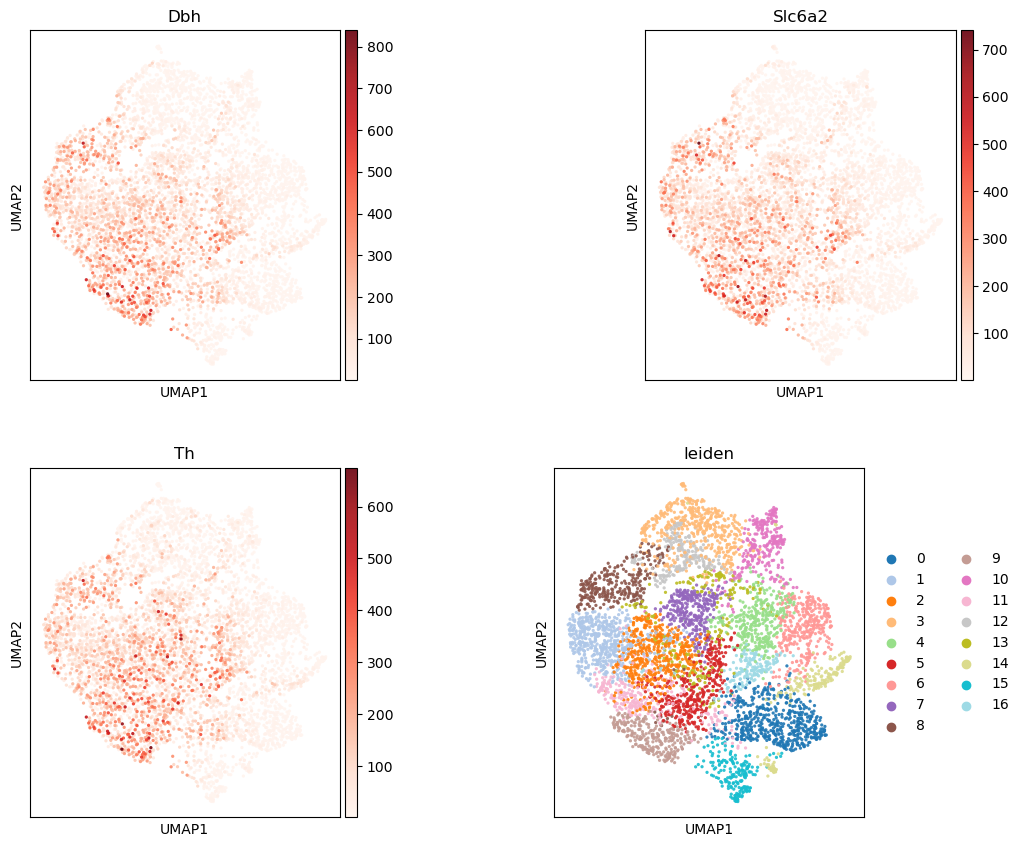

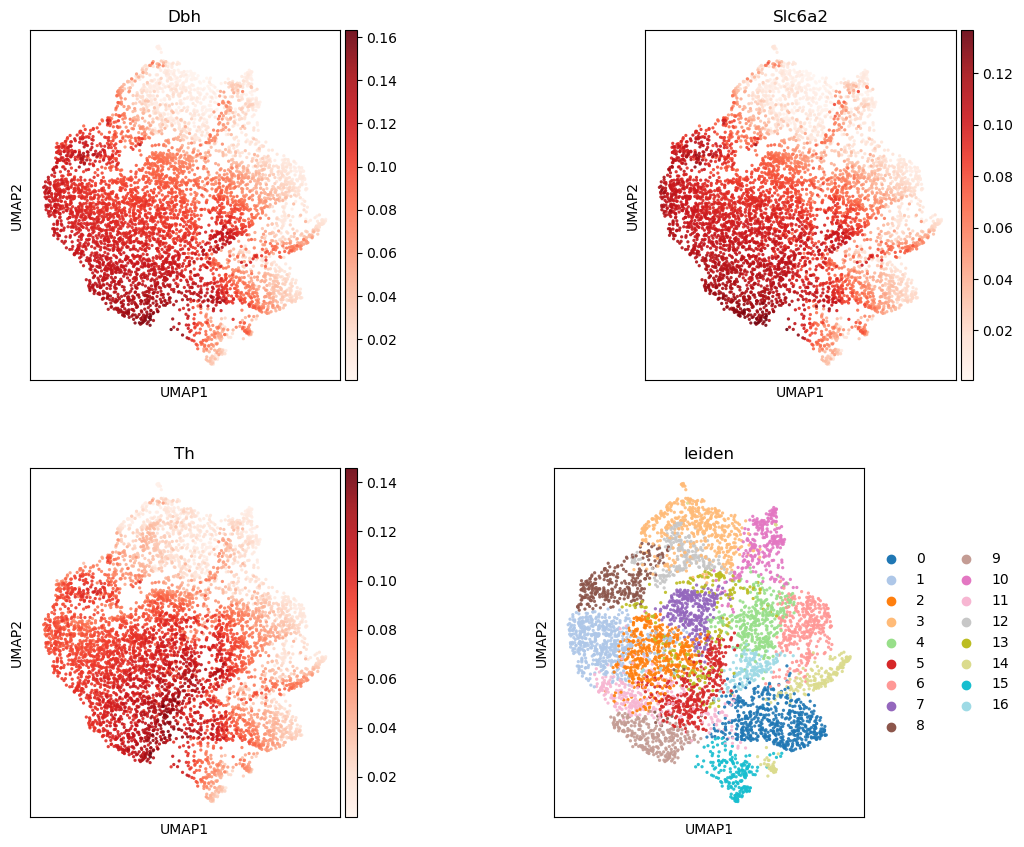

In [23]:
axes = sc.pl.umap(adata_mer, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')
    
axes = sc.pl.umap(adata_BN, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')    

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

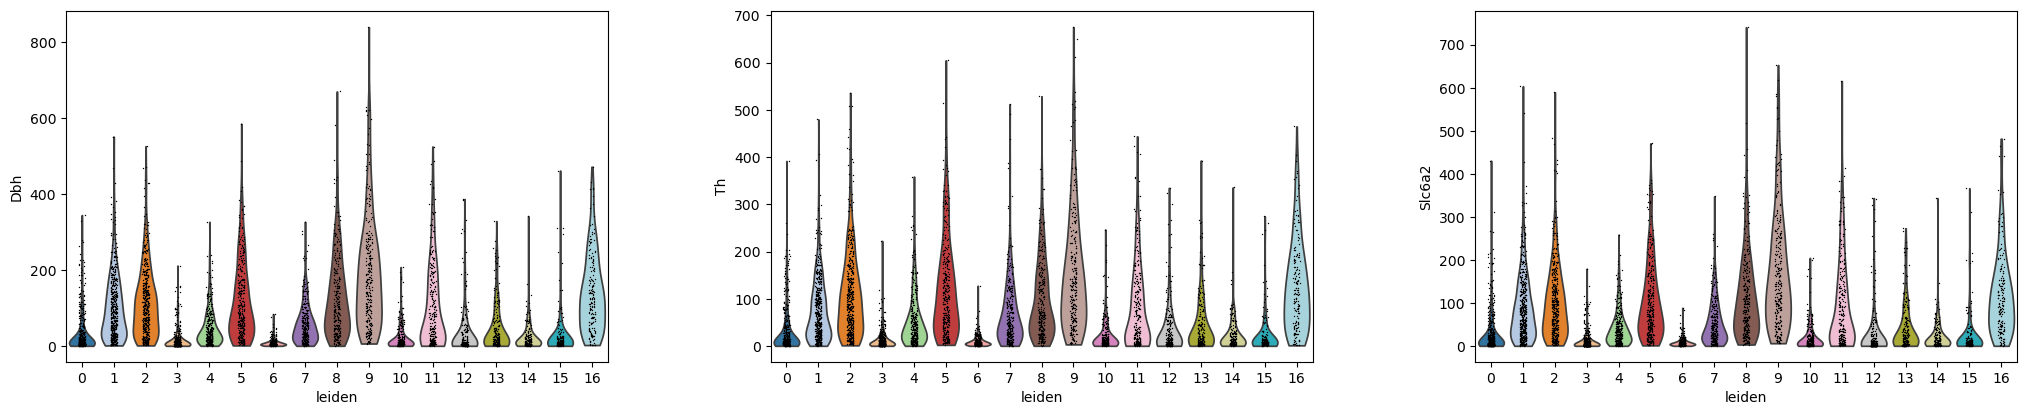

In [24]:
# check expression of the LC-NE markers across Leiden clusters
sc.pl.violin(adata_mer, markergenes, groupby='leiden')

## Select the LC-NE clusters
Keep Leiden clusters whose mean expression of all three markers (Dbh, Th, Slc6a2) is above the cross-cluster average (z-score > 0).

In [25]:
libsize = np.sum(adata_mer.X)
expr = pd.DataFrame(
    1000*adata_mer[:, markergenes].X/libsize,
    columns=markergenes,
    index=adata_mer.obs_names
)
expr['leiden'] = adata_mer.obs['leiden'].values
cluster_means = expr.groupby('leiden')[markergenes].mean()
cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()
cluster_z

/tmp/ipykernel_13051/1932138714.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = expr.groupby('leiden')[markergenes].mean()


,Dbh,Th,Slc6a2
leiden,,,
0,-0.733864,-0.796821,-0.729446
1,0.543024,0.251525,0.534118
2,0.783860,1.015132,0.794345
3,-1.045205,-1.152375,-1.075282
4,-0.447673,-0.242138,-0.462887
5,0.903318,1.247606,0.889079
6,-1.173000,-1.213008,-1.140065
7,-0.238570,0.124732,-0.180254
8,1.085933,0.735094,1.066330


In [26]:
chosen_ks = cluster_z[
    (cluster_z['Dbh'] > 0) &
    (cluster_z['Th'] > 0) &
    (cluster_z['Slc6a2'] > 0)
].index.astype(int).tolist()
chosen_ks.sort()

# ### if we want to remove the cluster 0 
# threshold = 0  # or 0.5
# chosen_ks = cluster_z[
#     (cluster_z > threshold).all(axis=1)
# ].index.astype(int).tolist()

print("Selected clusters:", chosen_ks)

Selected clusters: [1, 2, 5, 8, 9, 11, 16]


In [27]:
mask = adata_mer.obs['leiden'].isin([str(k) for k in chosen_ks])
adata_subset = adata_mer[mask].copy()
subset_leiden = np.array(adata_subset.obs['leiden'].copy())
print(f"Original size: {adata_mer.n_obs} cells")
print(f"Subset size: {adata_subset.n_obs} cells")

Original size: 5473 cells
Subset size: 2346 cells


# visualize them 

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

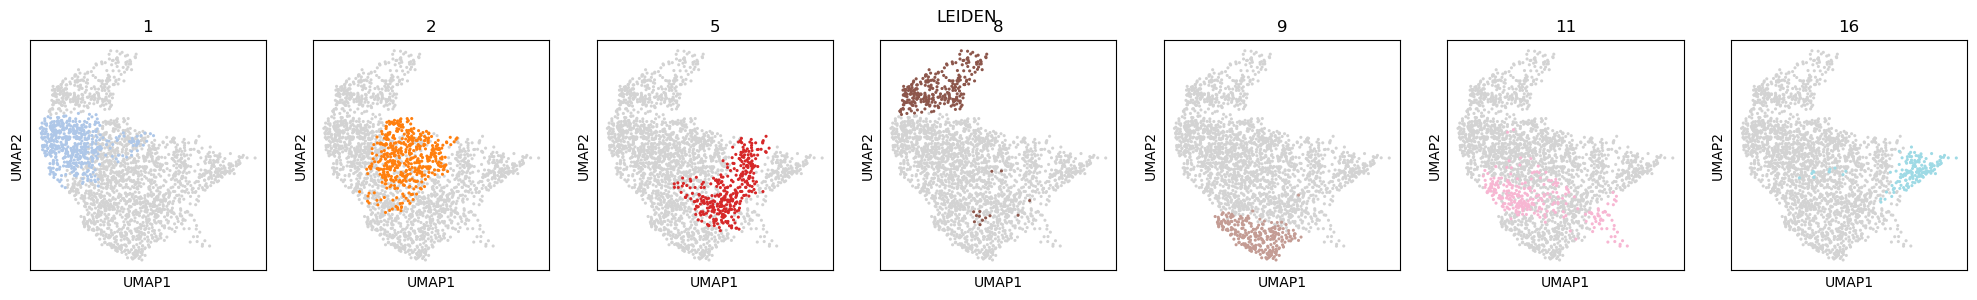

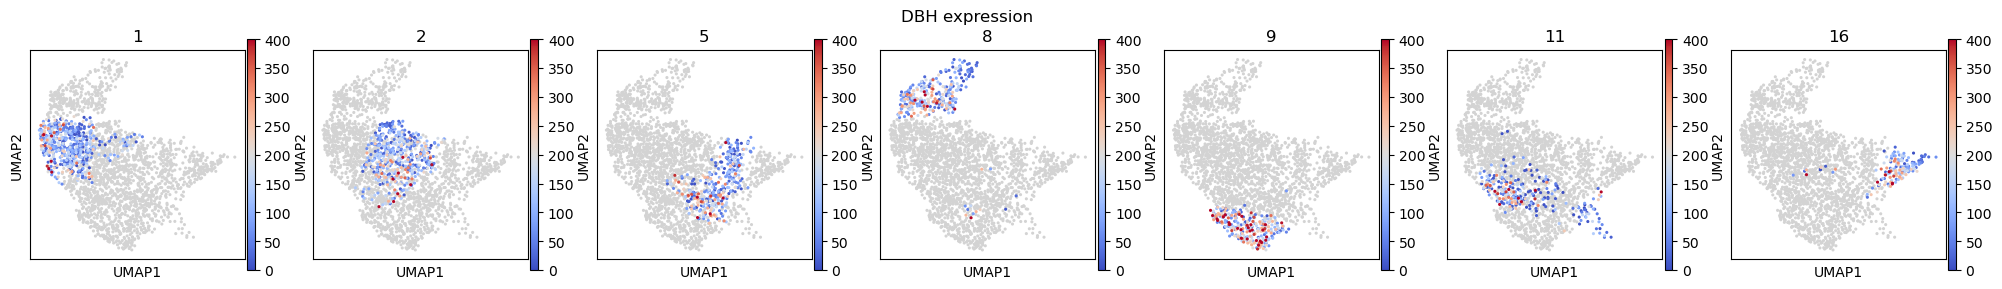

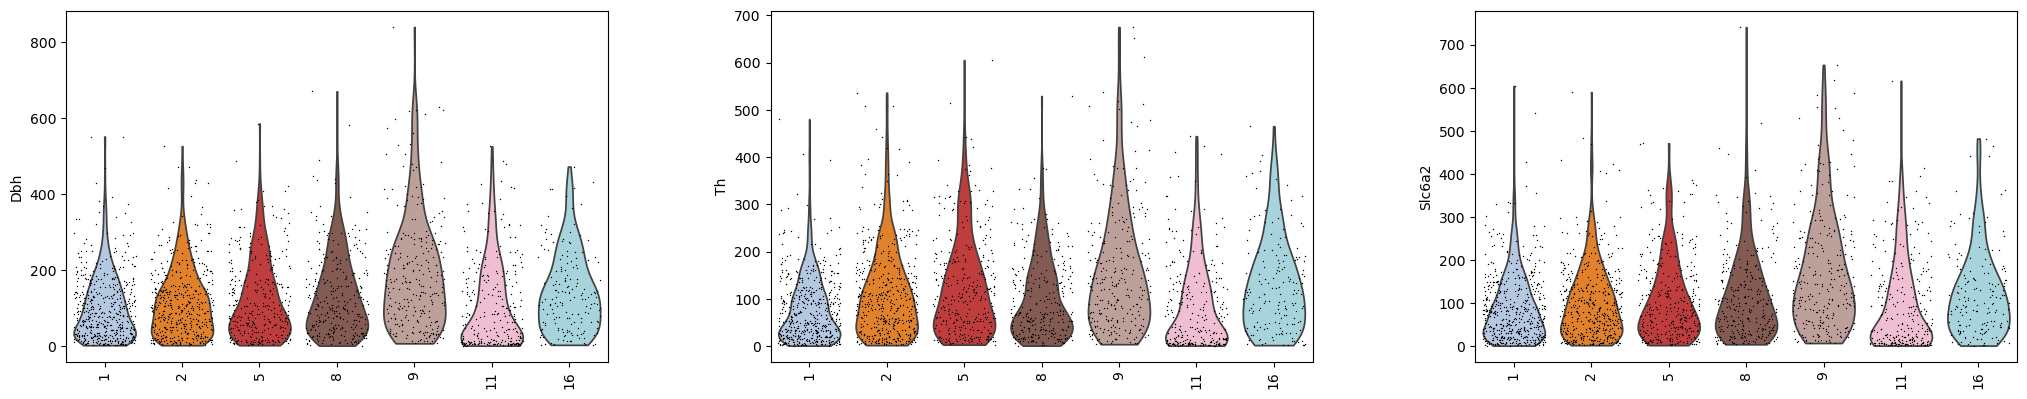

In [28]:
fig, axes = plt.subplots(1, len(chosen_ks), figsize=(25,3))
for i,k in enumerate(chosen_ks):
    sc.pl.umap(adata_subset, mask_obs=(subset_leiden==str(k)), color='leiden',
               ax=axes[i], size=20, alpha=1, title=str(k), show=False, legend_loc=None)
    axes[i].set_aspect('equal')
fig.suptitle('LEIDEN')

fig, axes = plt.subplots(1, len(chosen_ks), figsize=(25,3))
for i,k in enumerate(chosen_ks):
    sc.pl.umap(adata_subset, mask_obs=(subset_leiden==str(k)), color='Dbh', cmap='coolwarm',
               vmax=400, vmin=0,
               ax=axes[i], size=20, alpha=1, title=str(k), show=False, legend_loc=None)
    axes[i].set_aspect('equal')
fig.suptitle('DBH expression')

sc.pl.violin(
    adata_subset,
    keys=markergenes, groupby="leiden", use_raw=True,
    jitter=0.4, rotation=90, multi_panel=True)

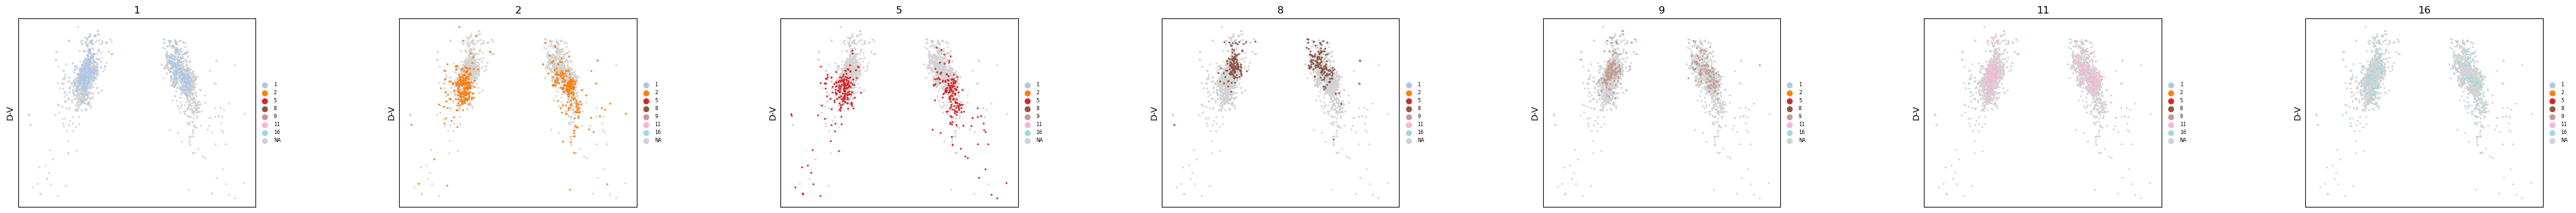

In [29]:
fig, axes = plt.subplots(1, len(chosen_ks), figsize=(55,4))
for i,k in enumerate(chosen_ks):
    sc.pl.embedding(adata_subset, mask_obs=(subset_leiden==str(k)), color='leiden', ax=axes[i],
                    dimensions=(2, 1), basis="spatial", size=20, alpha=1,
                    title=str(k), show=False, legend_fontsize='xx-small')
    axes[i].invert_yaxis()
    axes[i].set_aspect('equal')
    axes[i].set_ylabel('D-V')
    axes[i].set_xlabel('')

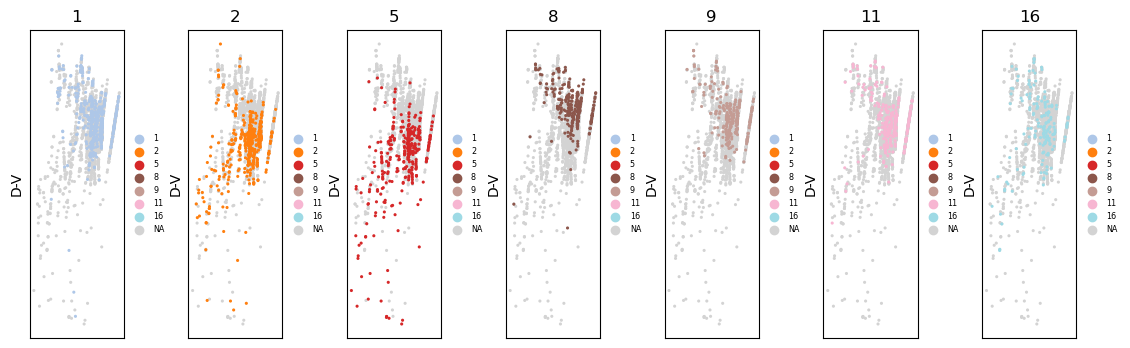

In [30]:
fig, axes = plt.subplots(1, len(chosen_ks), figsize=(14,4))
for i,k in enumerate(chosen_ks):
    sc.pl.embedding(adata_subset, mask_obs=(subset_leiden==str(k)), color='leiden', ax=axes[i],
                    dimensions=(0, 1), basis="spatial", size=20, alpha=1,
                    title=str(k), show=False, legend_fontsize='xx-small')
    axes[i].invert_yaxis()
    axes[i].set_aspect('equal')
    axes[i].set_ylabel('D-V')
    axes[i].set_xlabel('')

## add folded coordinates

In [31]:
MESH_MIDLINE = 227.5106275


def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, xm=MESH_MIDLINE):#, meshhome=None):
    '''
    Fold coordinates onto one hemisphere by mirroring points that lie past the mesh's midline. 
    Axis of interest is assumed to be the last axis.
    xm is hand-calculated previouslay (227.5106275)
    '''
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)

adata_subset = adata_mer[mask].copy() 
adata_subset.obsm['spatial_hemi'] = get_hemi(adata_subset.obsm['spatial'])
adata_subset.obs['sex'] = adata_subset.obs['mouse_sex']

# save results

In [32]:
os.makedirs(paths['result'], exist_ok=True)

filename = os.path.join(paths['result'],'adata_mer_subset_2_2k.h5ad')
adata_subset.write(filename)


In [33]:
print('done,size:',adata_subset.shape)

done,size: (2346, 315)
